# **Section 4: Logistic Regression Classification**

In this notebook, I will train and evaluate Logistic Regression models. I will start with a baseline model using default parameters, and will then tune the regularization parameter (C) using a cross-validated grid search.

## **1. Importing the Data**

Let's import the training, validation, and test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load SNP Features**

In [2]:
# Load SNP features and labels
snp_data = pd.read_csv('snps_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = snp_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (227, 9754)
Label shape: (227, 1)
Categories: [0 1]


### **1.2 Split Data into Train, Validation, and Test Sets**

In [3]:
# First split: 70% train+val, 30% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 70% train (from remaining), 30% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (110, 9754)
Validation set shape: (48, 9754)
Test set shape: (69, 9754)


## **2. Logistic Regression with Default Hyperparameters**

Let's start with a baseline Logistic Regression model using default parameters (C=1.0).

In [4]:
# Create Logistic Regression pipeline with standardization
# StandardScaler is important for logistic regression
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Train the model
print("Training Logistic Regression with C=1.0...")
logreg.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Training Logistic Regression with C=1.0...
Logistic Regression model trained successfully!


### **2.1 Evaluate Baseline Model**

In [5]:
# Evaluate on training, validation, and test sets
accuracy_train = logreg.score(X_train, y_train)
accuracy_val = logreg.score(X_val, y_val)
accuracy_test = logreg.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy validation set: {accuracy_val:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy validation set: 0.8750
Accuracy test set: 0.7101


### **2.2 Classification Report and Confusion Matrix**

In [6]:
# Get predictions
y_test_pred = logreg.predict(X_test)

# Classification report
print("Classification Report (Baseline Logistic Regression):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline Logistic Regression):
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        32
           1       0.71      0.78      0.74        37

    accuracy                           0.71        69
   macro avg       0.71      0.70      0.71        69
weighted avg       0.71      0.71      0.71        69



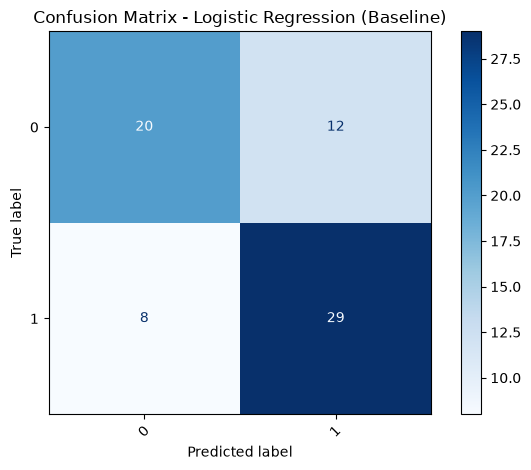

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing Regularization C**

Now let's use cross-validated grid search to find the optimal regularization parameter C.

### **3.1 Combine Training and Validation Sets**

In [8]:
# Combine train and validation sets
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_total.shape}")
print(f"Combined training set labels shape: {y_train_total.shape}")

Combined training set shape: (158, 9754)
Combined training set labels shape: (158, 1)


### **3.2 Grid Search for Optimal Hyperparameters**

In [9]:
# Create Logistic Regression pipeline
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=1)
)

# Define parameter grid
param_grid = {
    'logisticregression__C': np.logspace(-2, 3, 6)  # 0.01 to 1000
}

# Create grid search
grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
print("Performing grid search")
grid_search.fit(X_train_total, y_train_total)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Performing grid search...

Best parameters: {'logisticregression__C': np.float64(1000.0)}
Best cross-validation score: 0.8300


### **3.3 Analyze Grid Search Results**

In [ ]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_logisticregression__C'
]].sort_values('mean_test_score', ascending=False)

print("\nGrid Search Results:")
print(results_display)

### **3.4 Visualize Training/Validation Curves by C**

In [ ]:
# Sort results by C value for plotting
cv_results_sorted = cv_results.sort_values('param_logisticregression__C')

plt.figure(figsize=(10, 6))
plt.semilogx(
    cv_results_sorted['param_logisticregression__C'],
    cv_results_sorted['mean_train_score'],
    label='Training Accuracy',
    marker='o',
    linewidth=2
)
plt.semilogx(
    cv_results_sorted['param_logisticregression__C'],
    cv_results_sorted['mean_test_score'],
    label='Validation Accuracy',
    marker='s',
    linewidth=2
)

plt.xlabel('Regularization Parameter C (log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Logistic Regression: Training and Validation Accuracy vs C', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **4. Evaluate Best Model**

In [ ]:
# Evaluate best model on test set
best_logreg = grid_search.best_estimator_
accuracy_test_best = best_logreg.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

### **4.1 Classification Report**

In [ ]:
# Get predictions
y_test_pred_best = best_logreg.predict(X_test)

# Classification report
print("\nClassification Report (Best Logistic Regression):")
print(classification_report(y_test, y_test_pred_best))

### **4.2 Confusion Matrix**

In [ ]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_logreg.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_logreg.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best Logistic Regression (C={grid_search.best_params_['logisticregression__C']:.4f})")
plt.tight_layout()
plt.show()

### **4.3 ROC Curve and AUC Score**

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_logreg.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best Logistic Regression (C={grid_search.best_params_["logisticregression__C"]:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Results**

In [ ]:
import csv
import os

# Store results
results = {
    'model': 'Logistic Regression',
    'hyperparameters': f"C={grid_search.best_params_['logisticregression__C']:.4f}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")